In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

import json
import scipy.stats

from utils.constants import *
from utils.logging import LOGGER
from utils.datagen import load_s3_data_as_df, load_local_data_as_df

from generative_models.data_synthesiser_utils.datatypes.FloatAttribute import FloatAttribute
from generative_models.data_synthesiser_utils.datatypes.IntegerAttribute import IntegerAttribute
from generative_models.data_synthesiser_utils.datatypes.StringAttribute import StringAttribute

from generative_models.generative_model import GenerativeModel

from utils.constants import *
from utils.logging import LOGGER

import subprocess
import os
import json
import tempfile

from datetime import datetime
from pathlib import Path

/uio/hume/student-u82/beritoo/Documents/synthetic_data_release/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
class DataDescriber(object):
    def __init__(self, metadata, histogram_bins, infer_ranges=False):
        self.metadata = metadata
        self.histogram_bins = histogram_bins
        self.infer_ranges = infer_ranges

        self.attr_dict = None
        self.attr_names = None

    def describe(self, df):
        self.attr_names = self._get_attr_names()
        self.attr_dict = self._represent_input_dataset_by_columns(df)

        for col, Attribute in self.attr_dict.items():
            Attribute.infer_distribution()

    def _get_attr_names(self):
        return [c for c in self.metadata.keys()]

    def _represent_input_dataset_by_columns(self, df):
        attr_dict = {}

        for col, cdict in self.metadata.items():
            coltype = cdict['type']

            paras = (col, df[col], self.histogram_bins)
            if coltype in NUMERICAL:
                if coltype == FLOAT:
                    Attribute = FloatAttribute(*paras)
                else:
                    Attribute = IntegerAttribute(*paras)

                if self.infer_ranges:
                    cmin, cmax = min(df[col]), max(df[col])
                else:
                    cmin, cmax = cdict['min'], cdict['max']

                Attribute.set_domain(domain=(cmin, cmax))

            elif coltype in STRINGS:
                Attribute = StringAttribute(*paras)
                if self.infer_ranges:
                    ccats = list(df[col].unique())
                else:
                    ccats = cdict['categories']

                Attribute.set_domain(domain=ccats)

            else:
                raise Exception(f'The DataType of {col} is unknown.')

            attr_dict[col] = Attribute

        return attr_dict

In [3]:
class IMRV(GenerativeModel):
    def __init__(self,
                 metadata,
                 family_set = "parametric",
                 sensitive = None,
                 weight = 0,
                 trunc_lvl = None,
                 histogram_bins = 45,
                 infer_ranges = False,
                 multiprocess = True):
        """An Independence Mixture R-Vine (IMRV) copula model

        Args:
            metadata (_type_): _description_
            family_set (str, optional): _description_. Defaults to "parametric".
            sensitive (_type_, optional): _description_. Defaults to None.
            weight (int, optional): _description_. Defaults to 0.
            trunc_lvl (_type_, optional): _description_. Defaults to None.
            histogram_bins (int, optional): _description_. Defaults to 45.
            infer_ranges (bool, optional): _description_. Defaults to False.
            multiprocess (bool, optional): _description_. Defaults to True.
        """
        self.metadata = self._read_meta(metadata)
        self.family_set = family_set
        self.sensitive = sensitive
        self.weight = weight 
        self.histogram_bins = histogram_bins
        self.multiprocess = bool(multiprocess)
        self.infer_ranges = bool(infer_ranges)
        
        self.d = len(metadata['columns'])
        self.trunc_lvl = trunc_lvl if trunc_lvl is not None else self.d - 1
        self.var_types = ['c' if metadata['columns'][i]['type'] == 'Float' else 'd' for i in range(self.d)]
        
        self.datatype = pd.DataFrame
        self.__name__ = f'IMRV({self.weight})'
        self.DataDescriber = None
        self.trained = False

    def fit(self, data):
        n = data.shape[0]
        # Store real data for transformation of margins in generate_sampels function
        self.real_data = data

        # Get columns indices of sensitive variables
        if len(set(self.sensitive).intersection(data.columns)) != len(self.sensitive):
                    raise ValueError("Sensitive variables must be in data frame")
        
        sensitive_ind = []
        if self.sensitive is not None:
            sensitive_ind = [j+1 for j in range(self.d) if data.columns[j] in self.sensitive]

        # Compute pseudo-observations     
        u_data = []
        for j in range(self.d):
            if self.var_types[j] == "c":
                u_data.append(scipy.stats.rankdata(data.iloc[:,j]))
            else:
                u_data.append(scipy.stats.rankdata(data.iloc[:,j], method="max"))

        for j in range(self.d):
            if self.var_types[j] == "d":
                u_data.append(scipy.stats.rankdata(data.iloc[:,j], method="min")-1)
            else:
                pass            

        u_data = np.array(u_data).transpose() * 1/(n+1)
        # u_data = pv.to_pseudo_obs(data.to_numpy())

        # Set controls 
        family_set_dict = {"all":pv.all, 
                           "parametric":pv.parametric, 
                           "one_par":pv.one_par, 
                           "two_par":pv.two_par, 
                           "three_par":pv.three_par, 
                           "nonparametric":pv.nonparametric}

        controls = pv.FitControlsVinecop(family_set=family_set_dict[self.family_set], trunc_lvl=self.trunc_lvl)
        
        # Fit vine copula model to data
        self.vc0 = pv.Vinecop(d=self.d).from_data(u_data, controls=controls, var_types=self.var_types)

        # Define independence mixture component
        M = self.vc0.structure.matrix
        pair_copulas1 = self.vc0.pair_copulas

        for j in range(self.d-1):
            for k in range(self.d-j-1):
                conditioned = (M[j,k], M[self.d-k-1,k])
                sensitive_dep = (conditioned[0] in sensitive_ind) or (conditioned[1] in sensitive_ind)
                if sensitive_dep: # Replace "sensitive" pair copula with independence pair copula
                    pair_copulas1[j][k] = pv.Bicop(pv.indep)

        self.vc1 = pv.Vinecop(d=self.d).from_structure(structure=self.vc0.structure, 
                                                       pair_copulas=pair_copulas1, 
                                                       var_types=self.vc0.var_types)

    def generate_samples(self, nsamples):
        # Sample latent variables
        c = np.random.choice([0,1], size=nsamples, replace=True, p=[1-self.weight,self.weight])
        n1, n0 = c.sum(), nsamples - c.sum()

        # Simulate from fitted vines conditional on latent variables
        u_synth = np.zeros((nsamples, self.d))
        u_synth[c==0,] = self.vc0.simulate(n0)
        u_synth[c==1,] = self.vc1.simulate(n1)

        # Back-transform margins
        synth_data = []
        for i in range(self.d):
            if self.var_types[i] == "c":
                s = np.quantile(a = self.real_data.iloc[:,i], q = u_synth[:,i], method = 'median_unbiased')
                synth_data.append(s)
            else:
                s = np.quantile(a = self.real_data.iloc[:,i], q = u_synth[:,i], method = 'closest_observation')
                synth_data.append(s)
                                
        synth_data = pd.DataFrame(synth_data).transpose()
            
        synth_data.columns = list(self.real_data) 
            
        convert_dict = {col: object if dtype == 'd' else float for col, dtype in zip(synth_data.columns, self.var_types)}
        synth_data = synth_data.astype(convert_dict)
            
        return synth_data
             

    def _read_meta(self, metadata):
        """ Read metadata from metadata file."""
        metadict = {}

        for cdict in metadata['columns']:
            col = cdict['name']
            coltype = cdict['type']

            if coltype == FLOAT or coltype == INTEGER:
                metadict[col] = {
                    'type': coltype,
                    'min': cdict['min'],
                    'max': cdict['max']
                }

            elif coltype == CATEGORICAL or coltype == ORDINAL:
                metadict[col] = {
                    'type': coltype,
                    'categories': cdict['i2s'],
                    'size': len(cdict['i2s'])
                }

            else:
                raise ValueError(f'Unknown data type {coltype} for attribute {col}')

        return metadict

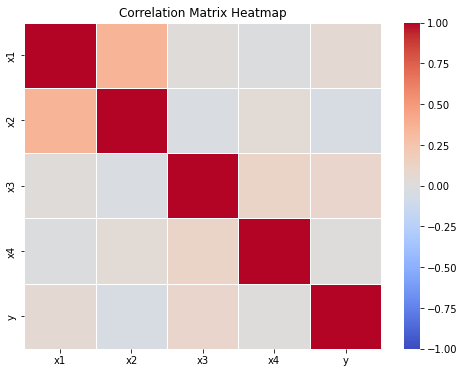

In [4]:
s3name = "../data/test/test"
data, metadata = load_local_data_as_df(s3name)

data.head()

gm = IMRV(metadata, family_set="one_par", sensitive = ["x1", "x4"], weight=0.5)
gm.fit(data)
synth_data = gm.generate_samples(1000)

corr_matrix = synth_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

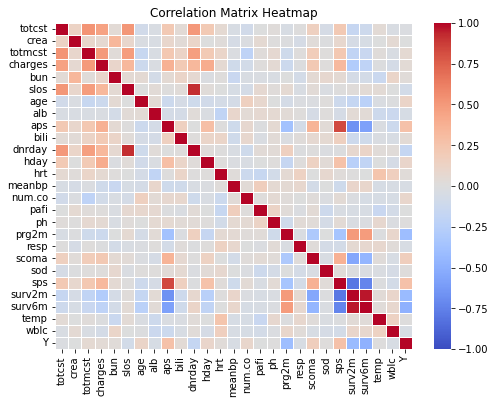

In [5]:
s3name = "../data/support2/real_support2_small"
data, metadata = load_local_data_as_df(s3name)

data.head()

gm = IMRV(metadata, family_set="one_par", sensitive = ["totcst", "crea"], weight=0.5)
gm.fit(data)
synth_data = gm.generate_samples(1000)

corr_matrix = synth_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [6]:
data.loc[['ID447', 'ID1124', 'ID84'],:]

,totcst,crea,totmcst,charges,bun,slos,age,alb,aps,bili,...,prg2m,resp,scoma,sod,sps,surv2m,surv6m,temp,wblc,Y
ID,,,,,,,,,,,,,,,,,,,,,
ID447,77842.5625,1.199951,96503.1875,121636.0,25.0,58.0,79.54797,3.199707,71.0,1.399902,...,0.7,24.0,9.0,137.0,25.000000,0.566895,0.454956,36.50000,36.398438,1
ID1124,15879.9141,0.899902,14567.7266,24143.0,19.0,15.0,83.23297,3.199707,29.0,1.099854,...,0.8,36.0,9.0,142.0,26.199219,0.659912,0.561890,36.39844,14.398438,1
ID84,11643.9219,2.399902,15341.6094,24810.0,37.0,18.0,83.11798,3.299805,62.0,1.299805,...,0.5,32.0,0.0,145.0,34.796875,0.481995,0.363953,36.09375,26.097656,1


In [7]:
data.head()

,totcst,crea,totmcst,charges,bun,slos,age,alb,aps,bili,...,prg2m,resp,scoma,sod,sps,surv2m,surv6m,temp,wblc,Y
ID,,,,,,,,,,,,,,,,,,,,,
ID0,2658.7598,4.500000,3309.26953,4010.0,147.0,4.0,70.38495,2.299805,37.0,5.500000,...,0.1,8.0,9.0,146.0,41.593750,0.046997,0.001000,37.79688,41.398438,1
ID1,21783.8438,0.799927,24751.82810,30122.0,19.0,34.0,49.20200,3.299805,52.0,1.500000,...,0.9,10.0,9.0,140.0,35.195312,0.663940,0.488953,35.09375,8.298828,1
ID2,2168.3652,1.299805,2810.16992,3065.0,36.0,4.0,43.75400,2.899902,67.0,2.799805,...,0.0,30.0,0.0,154.0,47.796875,0.031998,0.000000,36.59375,15.099609,1
ID3,26061.3438,6.299805,28384.95310,38899.0,80.0,38.0,54.93997,2.399902,10.0,0.699951,...,0.3,27.0,0.0,139.0,15.898438,0.830933,0.796997,38.19531,6.099609,1
ID4,10966.8984,0.899902,12575.00000,16234.0,19.0,17.0,57.02899,3.299805,22.0,2.599609,...,0.5,10.0,0.0,146.0,26.699219,0.494995,0.174988,38.50000,3.000000,1


In [8]:
columns = np.array([col["name"] for col in metadata["columns"]])
types = np.array([col["type"] for col in metadata["columns"]])
cat_cols = columns[np.isin(types, ["Categorical", "Ordinal"])]
cont_cols = np.setdiff1d(data.columns,cat_cols)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_values = scaler.fit_transform(data[cont_cols])
standSample = pd.DataFrame(data=scaled_values, columns=cont_cols)

In [10]:
standSample

,age,alb,aps,bili,bun,charges,crea,dnrday,hday,hrt,...,scoma,slos,sod,sps,surv2m,surv6m,temp,totcst,totmcst,wblc
0,0.451530,-0.485339,-0.083876,0.618380,4.044355,-0.592174,1.458095,-0.669966,-0.358428,0.094490,...,-0.118608,-0.722982,1.196022,1.798350,-2.504805,-2.136910,0.384022,-0.678891,-0.663304,3.108833
1,-0.905780,0.418204,0.661115,-0.186651,-0.587141,-0.302575,-0.615583,-0.500120,-0.358428,0.363065,...,-0.118608,0.890342,0.247814,1.086502,0.103449,-0.161251,-1.620271,-0.197442,-0.173806,-0.609685
2,-1.254864,0.056875,1.406106,0.074945,0.027980,-0.602655,-0.335430,-0.613351,-0.358428,1.377680,...,-0.499261,-0.722982,2.460298,2.488469,-2.568218,-2.140959,-0.508064,-0.691236,-0.674697,0.154337
3,-0.538116,-0.394897,-1.424859,-0.347667,1.620057,-0.205232,2.466782,0.632190,-0.358428,-0.920126,...,-0.499261,1.105451,0.089780,-1.060342,0.809442,1.085982,0.679446,-0.089761,-0.090868,-0.856752
4,-0.404261,0.418204,-0.828867,0.034654,-0.587141,-0.456602,-0.559552,0.179266,-0.358428,0.333223,...,-0.499261,-0.023875,1.196022,0.141282,-0.610802,-1.432455,0.905365,-0.469745,-0.451783,-1.204973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,1.461621,0.327761,0.015456,-0.307425,-0.514774,-0.465009,-0.447491,-0.273658,-0.358428,0.303381,...,3.730221,-0.400318,-0.068255,-0.337195,-2.365335,-1.958767,-0.803496,-0.495518,-0.514086,-0.778090
1156,0.607620,0.327761,1.902767,-0.387909,-0.370039,-0.536388,-0.671613,-0.613351,-0.358428,0.780848,...,-0.499261,-0.722982,1.037987,1.287280,-0.999924,-0.991092,-0.432760,-0.673633,-0.573939,1.895438
1157,-2.674844,-0.394897,-1.722856,-0.307425,-0.550957,-0.246012,-0.615583,0.349113,-0.358428,1.198631,...,1.361711,0.137457,-1.332531,-1.093588,1.168632,1.441840,1.200797,-0.180434,-0.262719,1.895438
1158,0.053111,0.056875,0.114789,0.376831,-1.093711,-0.606404,-0.671613,-0.556735,-0.358428,-1.069334,...,-0.499261,-0.722982,-0.068255,0.285999,0.496700,0.349059,-0.357449,-0.745822,-0.738849,-1.103875
